<a href="https://www.kaggle.com/code/muhammadumarusman/cfpb-02-tf-idf-baseline-complaint-router?scriptVersionId=354741122" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CFPB Complaint Routing — Phase 2: TF-IDF Baseline Router
**Goal:** given a complaint narrative, predict which of 9 product teams should handle it.

This notebook builds the classical-ML baseline that every later model (DistilBERT in Phase 3) must beat:
1. Light text tidy-up (fixes leftovers from PII redaction found in Phase 1)
2. **Time-based split** — train on the past, test on the future, like a real deployment
3. Compare Complement Naive Bayes, Logistic Regression and Linear SVM on TF-IDF features
4. Tune on a validation window, evaluate once on the held-out test window
5. Error analysis, most predictive words per team, and a **confidence-based routing policy** (auto-route vs. send to a human)

Runs on **Kaggle Notebooks** (CPU, ~30 GB RAM, Internet **on**). The first section rebuilds the Phase 1 sample directly from the archived Hugging Face snapshot with the same filters and random seed, so this notebook is self-contained.

## 1. Setup

In [1]:
import os, re, time, json, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import joblib
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 300)
SEED = 42
OUT_DIR = "/kaggle/working"

## 1b. Data: rebuild the Phase 1 sample
Same recipe as Phase 1: stream the archived CFPB snapshot, keep complaints since 2020 with a narrative, take a seeded 15% sample per batch, map products to 9 routing teams, strip redaction tokens, deduplicate, drop texts under 10 words. If a cached `cfpb_sample.parquet` is attached as a Kaggle input, it is used instead.

In [2]:
import glob
cached = glob.glob("/kaggle/input/**/cfpb_sample.parquet", recursive=True)
if cached:
    df = pd.read_parquet(cached[0]); print("loaded cached sample:", cached[0])
else:
    !pip -q install -U huggingface_hub
    from huggingface_hub import hf_hub_download
    import pyarrow.parquet as pq
    PQ = hf_hub_download("vivekkopthsd/cfpb-consumer-complaints", "complaints.parquet",
                         repo_type="dataset", local_dir="/kaggle/temp")
    pf = pq.ParquetFile(PQ)
    COLS = ["date_received", "product", "sub_product", "issue", "sub_issue", "narrative",
            "company", "state", "company_response", "timely_response", "complaint_id"]
    START = pd.Timestamp("2020-01-01"); parts = []
    for batch in pf.iter_batches(batch_size=250_000, columns=COLS):
        chunk = batch.to_pandas()
        chunk["date_received"] = pd.to_datetime(chunk["date_received"], errors="coerce")
        chunk = chunk[chunk["narrative"].notna() & (chunk["narrative"].str.len() > 0)]
        chunk = chunk[chunk["date_received"] >= START]
        parts.append(chunk.sample(frac=0.15, random_state=SEED))
    df = pd.concat(parts, ignore_index=True); del parts; gc.collect()

    PRODUCT_MAP = {
        "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
        "Credit reporting or other personal consumer reports": "Credit reporting",
        "Credit reporting": "Credit reporting",
        "Debt collection": "Debt collection", "Debt or credit management": "Debt collection",
        "Credit card or prepaid card": "Credit card", "Credit card": "Credit card",
        "Prepaid card": "Prepaid / money transfer",
        "Money transfer, virtual currency, or money service": "Prepaid / money transfer",
        "Money transfers": "Prepaid / money transfer", "Virtual currency": "Prepaid / money transfer",
        "Checking or savings account": "Bank account", "Bank account or service": "Bank account",
        "Mortgage": "Mortgage", "Vehicle loan or lease": "Vehicle loan", "Consumer Loan": "Vehicle loan",
        "Student loan": "Student loan",
        "Payday loan, title loan, or personal loan": "Personal / payday loan",
        "Payday loan, title loan, personal loan, or advance loan": "Personal / payday loan",
        "Payday loan": "Personal / payday loan",
    }
    df["team"] = df["product"].map(PRODUCT_MAP).fillna("Other")

    def clean_text(s):
        s = re.sub(r"X{2,}/X{2,}/(X{2,}|\d{2,4})", " ", s)
        s = re.sub(r"\bX{2,}\b", " ", s)
        s = re.sub(r"\{\$[\d,.]+\}", " <amount> ", s)
        return re.sub(r"\s+", " ", s).strip()
    df["text"] = df["narrative"].map(clean_text)
    df["n_words"] = df["text"].str.split().str.len()
    df = df.drop_duplicates(subset="text")
    df = df[df["n_words"] >= 10].drop(columns="narrative").reset_index(drop=True)
    df.to_parquet(f"{OUT_DIR}/cfpb_sample.parquet", index=False)
print(df.shape)
print(df["team"].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.0/838.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
datasets 5.0.0 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 2.1.1 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 2.1.1 which is incompatible.
tokenizers 0.22.2 requires huggingface

complaints.parquet: reconstructing file:   0%|          |  0.00B / 1.02GB            

complaints.parquet: downloading bytes:           |  0.00B            

(341860, 13)
team
Credit reporting            205598
Debt collection              42385
Credit card                  25827
Bank account                 24440
Prepaid / money transfer     14812
Mortgage                     12500
Vehicle loan                  6558
Student loan                  5555
Personal / payday loan        4185
Name: count, dtype: int64


## 2. Tidy the text
Phase 1 removed redaction tokens (`XXXX`), which left fragments such as `On , I ...` and `( Payout IDs , , , , )`. We collapse those, then **deduplicate again** because tidying can make previously-different texts identical.

In [3]:
def tidy(s):
    s = re.sub(r"/?\s*/?year>", " ", s)            # leftover 'XX/XX/year>' fragments
    s = re.sub(r"(?:\s*[,/;:]\s*){2,}", ", ", s)     # runs of punctuation left by removed redactions
    s = re.sub(r"\(\s*[,\s]*\)", " ", s)             # empty parentheses
    s = re.sub(r"^\s*(On|on)\s*,\s*", "", s)          # 'On , I ...' -> 'I ...'
    s = re.sub(r"\s+([,.;:!?])", r"\1", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

before = df["text"].iloc[0]
df["text"] = df["text"].map(tidy)
print("BEFORE:", before[:200]); print("AFTER: ", df["text"].iloc[0][:200])
n0 = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"\nrows: {n0:,} -> {len(df):,} after re-dedup")

BEFORE: On , resolved 7 disputes in my favor. <amount> was credited to my balance. The remaining <amount> , across 5 payouts ( Payout IDs , , , , ), was never received. states these funds were sent to my Send
AFTER:  resolved 7 disputes in my favor. <amount> was credited to my balance. The remaining <amount>, across 5 payouts ( Payout IDs, ), was never received. states these funds were sent to my Send Account on o

rows: 341,860 -> 340,347 after re-dedup


## 3. Time-based split
A random split would let the model "see the future" — and near-duplicate template letters from the same month would land in both train and test, inflating scores. Instead:

| split | window | purpose |
|---|---|---|
| train | 2020-01 → 2024-12 | fit models |
| validation | 2025-01 → 2025-06 | choose model & hyper-parameters |
| test | 2025-07 → 2026-07 | final, untouched evaluation |

In [4]:
TRAIN_END, VAL_END = "2024-12-31", "2025-06-30"
train = df[df.date_received <= TRAIN_END]
val   = df[(df.date_received > TRAIN_END) & (df.date_received <= VAL_END)]
test  = df[df.date_received > VAL_END]
TEAMS = sorted(df["team"].unique())

split_dist = pd.DataFrame({name: d["team"].value_counts(normalize=True) for name, d in
                           [("train", train), ("val", val), ("test", test)]}).loc[TEAMS]
print({name: len(d) for name, d in [("train", train), ("val", val), ("test", test)]})
(split_dist * 100).round(1)

{'train': 219906, 'val': 59895, 'test': 60546}


,train,val,test
team,,,
Bank account,6.6,6.4,9.9
Credit card,7.8,4.8,9.4
Credit reporting,61.9,65.1,47.7
Debt collection,11.8,9.9,17.4
Mortgage,4.3,1.7,3.4
Personal / payday loan,1.2,0.8,1.9
Prepaid / money transfer,3.0,8.1,5.7
Student loan,1.6,1.7,1.7
Vehicle loan,1.9,1.3,2.8


Compare the class mix across windows — any shift here is **concept drift** the model has to survive.

## 4. TF-IDF features
- word unigrams + bigrams (bigrams capture phrases like *credit report*, *late fee*, *wire transfer*)
- `sublinear_tf` dampens very long, repetitive narratives
- `min_df=10` drops typos/rare tokens; `max_df=0.9` drops near-universal words; vocabulary capped at 200k
- fitted on **train only** to avoid leakage

In [5]:
TFIDF_KW = dict(ngram_range=(1, 2), min_df=10, max_df=0.9, sublinear_tf=True,
                max_features=200_000, strip_accents="unicode", dtype=np.float32)
t0 = time.time()
vec = TfidfVectorizer(**TFIDF_KW)
X_tr = vec.fit_transform(train["text"]); X_va = vec.transform(val["text"])
y_tr, y_va, y_te = train["team"].values, val["team"].values, test["team"].values
gc.collect()
print(f"vocab {len(vec.vocabulary_):,} | X_train {X_tr.shape} | {time.time()-t0:.0f}s")

vocab 200,000 | X_train (219906, 200000) | 68s


## 5. Compare baselines (on validation)
Metric: **macro-F1** — the average F1 across teams, so the tiny teams count as much as credit reporting. Accuracy is shown for reference only (predicting "Credit reporting" for everything would already score ~60%).

In [6]:
def evaluate(name, model, X, y):
    p = model.predict(X)
    return {"model": name, "macro_f1": f1_score(y, p, average="macro"),
            "weighted_f1": f1_score(y, p, average="weighted"), "accuracy": accuracy_score(y, p)}

majority = pd.Series(y_tr).mode()[0]
results = [{"model": "Majority class", "macro_f1": f1_score(y_va, [majority]*len(y_va), average="macro"),
            "weighted_f1": f1_score(y_va, [majority]*len(y_va), average="weighted"),
            "accuracy": accuracy_score(y_va, [majority]*len(y_va))}]
models = {
    "Complement NB": ComplementNB(alpha=0.3),
    "Logistic Regression": LogisticRegression(C=4, class_weight="balanced", solver="saga", max_iter=200, tol=1e-3),
    "Linear SVM": LinearSVC(C=0.5, class_weight="balanced"),
}
fit_times = {}
for name, m in models.items():
    t0 = time.time(); m.fit(X_tr, y_tr); fit_times[name] = time.time() - t0
    results.append(evaluate(name, m, X_va, y_va))
    print(f"{name:22s} fit {fit_times[name]:6.1f}s  val macro-F1 {results[-1]['macro_f1']:.3f}")
res = pd.DataFrame(results).set_index("model").round(3)
res

Complement NB          fit    1.0s  val macro-F1 0.619


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression    fit  525.6s  val macro-F1 0.704
Linear SVM             fit  159.4s  val macro-F1 0.750


,macro_f1,weighted_f1,accuracy
model,,,
Majority class,0.088,0.514,0.651
Complement NB,0.619,0.829,0.832
Logistic Regression,0.704,0.843,0.833
Linear SVM,0.750,0.873,0.872


## 6. Tune the regularisation strength `C` (validation set)

LinearSVC C=0.05  val macro-F1 0.7433
LinearSVC C=0.1   val macro-F1 0.7483
LinearSVC C=0.25  val macro-F1 0.7520
LinearSVC C=0.5   val macro-F1 0.7501
LinearSVC C=1.0   val macro-F1 0.7500


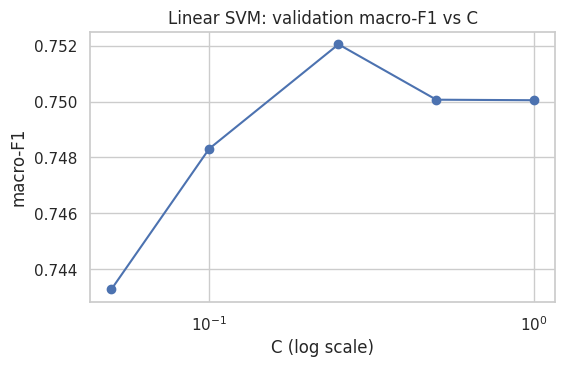

best C: 0.25


In [7]:
grid = {}
for C in [0.05, 0.1, 0.25, 0.5, 1.0]:
    m = LinearSVC(C=C, class_weight="balanced").fit(X_tr, y_tr)
    grid[C] = f1_score(y_va, m.predict(X_va), average="macro")
    print(f"LinearSVC C={C:<5} val macro-F1 {grid[C]:.4f}")
BEST_C = max(grid, key=grid.get)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(grid), list(grid.values()), marker="o"); ax.set_xscale("log")
ax.set(title="Linear SVM: validation macro-F1 vs C", xlabel="C (log scale)", ylabel="macro-F1")
plt.show(); print("best C:", BEST_C)

Small `C` = stronger regularisation (simpler model). The curve shows where the model stops under-fitting and starts over-fitting.

## 7. Final evaluation on the untouched test window
Refit the vectorizer + best model on **train + validation** (more recent data helps under drift), then score the test window exactly once.

In [8]:
del X_tr, X_va, vec, models; gc.collect()   # free RAM before the final refit
trval = pd.concat([train, val])
final_vec = TfidfVectorizer(**TFIDF_KW)
X_trval = final_vec.fit_transform(trval["text"]); X_test = final_vec.transform(test["text"])
svm = LinearSVC(C=BEST_C, class_weight="balanced").fit(X_trval, trval["team"])
pred = svm.predict(X_test)
test_metrics = {"macro_f1": f1_score(y_te, pred, average="macro"),
                "weighted_f1": f1_score(y_te, pred, average="weighted"),
                "accuracy": accuracy_score(y_te, pred)}
print({k: round(v, 3) for k, v in test_metrics.items()})
print(classification_report(y_te, pred, digits=3))

{'macro_f1': 0.781, 'weighted_f1': 0.839, 'accuracy': 0.841}
                          precision    recall  f1-score   support

            Bank account      0.780     0.817     0.798      6021
             Credit card      0.780     0.757     0.769      5718
        Credit reporting      0.886     0.934     0.909     28889
         Debt collection      0.846     0.726     0.782     10558
                Mortgage      0.871     0.915     0.893      2048
  Personal / payday loan      0.608     0.570     0.588      1149
Prepaid / money transfer      0.747     0.690     0.717      3430
            Student loan      0.805     0.828     0.816      1053
            Vehicle loan      0.753     0.762     0.757      1680

                accuracy                          0.841     60546
               macro avg      0.786     0.778     0.781     60546
            weighted avg      0.840     0.841     0.839     60546



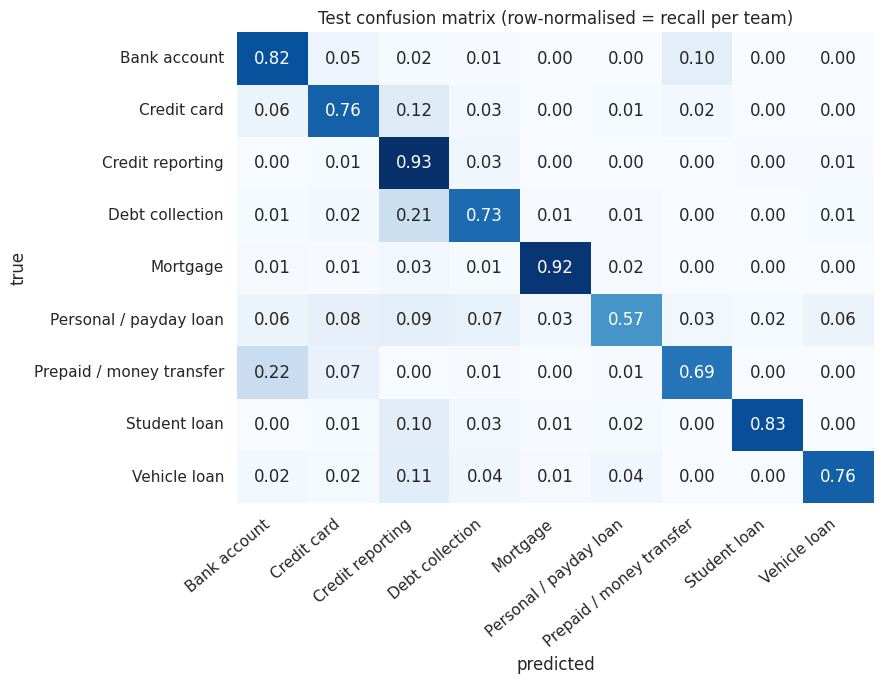

In [9]:
cm = confusion_matrix(y_te, pred, labels=TEAMS, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=TEAMS, yticklabels=TEAMS, ax=ax, cbar=False)
ax.set(title="Test confusion matrix (row-normalised = recall per team)", xlabel="predicted", ylabel="true")
plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()

Read each row: the diagonal is the share of that team's complaints routed correctly; off-diagonal cells show where they leak.

## 8. What did the model learn? Top words per team

In [10]:
feat = np.array(final_vec.get_feature_names_out())
rows = []
for i, team in enumerate(svm.classes_):
    top = np.argsort(svm.coef_[i])[-12:][::-1]
    rows.append({"team": team, "top features": ", ".join(feat[top])})
pd.DataFrame(rows).set_index("team")

,top features
team,
Bank account,"bank, chime, checking, funds, savings, debit card, branch, cd, chase, deposit, overdraft, banking"
Credit card,"card, synchrony, rewards, discover, barclays, comenity, balance transfer, citi, interest, mastercard, capital one, reliacard"
Credit reporting,"equifax, experian, transunion, inquiries, reporting, report, credit, inquiry, my report, lexisnexis, addresses, these"
Debt collection,"debt, collection, recovery, collections, owed, calls, threatened, associates, inc, garnishment, reason identity, resurgent"
Mortgage,"mortgage, escrow, heloc, home, modification, appraisal, loancare, foreclosure, closing, newrez, pennymac, loan"
Personal / payday loan,"loan, affirm, payday, upstart, personal loan, klarna, lending, netcredit, advance, greensky, acima, title loan"
Prepaid / money transfer,"coinbase, paypal, zelle, cashapp, venmo, money, cash app, wire, transfer, square, binance, gemini"
Student loan,"mohela, navient, edfinancial, nelnet, aidvantage, aes, loans, school, fedloan, student, firstmark, uas"
Vehicle loan,"vehicle, car, santander, bridgecrest, repossession, carvana, bmw, toyota, auto, acceptance, ally, lease"


## 9. Error analysis — the most common confusions

In [11]:
err = test.assign(pred=pred)
err = err[err.team != err.pred]
pairs = err.groupby(["team", "pred"]).size().sort_values(ascending=False).head(8)
print("Top confusions (true -> predicted):"); print(pairs)
for (t, p) in pairs.index[:3]:
    ex = err[(err.team == t) & (err.pred == p)].sample(1, random_state=SEED).iloc[0]
    print(f"\n--- true: {t} | predicted: {p} | issue: {ex.issue}")
    print(ex.text[:400])

Top confusions (true -> predicted):
team                      pred                    
Debt collection           Credit reporting            2199
Credit reporting          Debt collection              983
Prepaid / money transfer  Bank account                 745
Credit card               Credit reporting             687
Bank account              Prepaid / money transfer     579
Credit card               Bank account                 336
Credit reporting          Credit card                  330
Bank account              Credit card                  310
dtype: int64

--- true: Debt collection | predicted: Credit reporting | issue: Attempts to collect debt not owed
I am writing this formal statement to dispute the continued presence of negative accounts and collections currently appearing on my credit file. Please be advised that these accounts have already been fully settled and resolved. As such, their continued reporting as active negative items is inaccurate, misleading, and damaging

Many errors are *genuinely ambiguous* complaints (e.g. a debt collector reporting to a credit bureau touches two teams). That's a ceiling for any bag-of-words model and a motivation for Phase 3.

## 10. Confidence-based routing policy
In production we wouldn't blindly trust every prediction. A common design: **auto-route** when the model is confident, otherwise send to a **human triage queue**.
Linear SVM has no probabilities, so we use its *decision margin* (top score − second score) as confidence and trace the trade-off between how much is automated (coverage) and how accurate the automated part is.

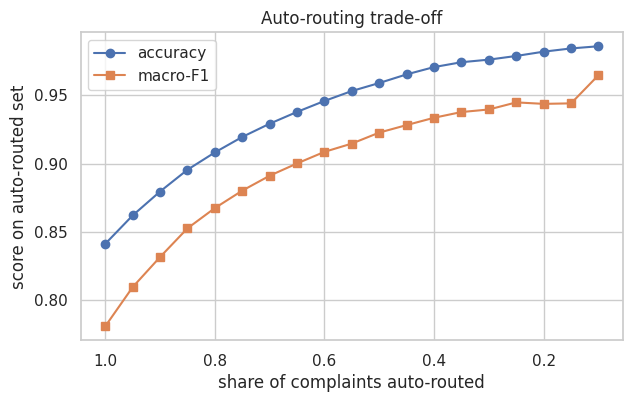

Highest coverage with >=95% accuracy:
 coverage  accuracy  macro_f1  threshold
     0.55     0.953     0.915       1.26


In [12]:
scores = svm.decision_function(X_test)
srt = np.sort(scores, axis=1)
margin = srt[:, -1] - srt[:, -2]
correct = (pred == y_te)
qs = np.linspace(0, 0.9, 19)
curve = []
for q in qs:
    thr = np.quantile(margin, q)
    keep = margin >= thr
    curve.append({"coverage": keep.mean(), "accuracy": correct[keep].mean(),
                  "macro_f1": f1_score(y_te[keep], pred[keep], average="macro"), "threshold": thr})
curve = pd.DataFrame(curve)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve.coverage, curve.accuracy, marker="o", label="accuracy")
ax.plot(curve.coverage, curve.macro_f1, marker="s", label="macro-F1")
ax.invert_xaxis(); ax.legend()
ax.set(title="Auto-routing trade-off", xlabel="share of complaints auto-routed", ylabel="score on auto-routed set")
plt.show()
target = curve[curve.accuracy >= 0.95].sort_values("coverage", ascending=False).head(1)
print("Highest coverage with >=95% accuracy:"); print(target.round(3).to_string(index=False))

## 11. Save the model and metrics

In [13]:
joblib.dump({"vectorizer": final_vec, "model": svm, "teams": TEAMS},
            f"{OUT_DIR}/tfidf_linearsvc.joblib", compress=3)
metrics = {"phase": 2, "model": f"TF-IDF(1-2gram) + LinearSVC(C={BEST_C}, balanced)",
           "train_window": f"2020-01-01..{VAL_END}", "test_window": f"{VAL_END}..",
           "n_train": int(len(trval)), "n_test": int(len(test)),
           "validation": res.reset_index().to_dict(orient="records"),
           "test": {k: round(float(v), 4) for k, v in test_metrics.items()}}
with open(f"{OUT_DIR}/phase2_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics["test"], indent=2))

{
  "macro_f1": 0.7811,
  "weighted_f1": 0.8393,
  "accuracy": 0.8414
}


In [14]:
def route(narrative: str):
    x = final_vec.transform([tidy(narrative)])
    s = svm.decision_function(x)[0]; o = np.argsort(s)[::-1]
    return {"team": svm.classes_[o[0]], "runner_up": svm.classes_[o[1]], "margin": round(float(s[o[0]] - s[o[1]]), 3)}

route("I noticed a late payment on my credit report from Experian that I never made. I disputed it twice and it is still there.")

{'team': 'Credit reporting', 'runner_up': 'Vehicle loan', 'margin': 2.603}

## Findings & next steps
*(filled in after running — see the README for the summary)*
- **Phase 3:** fine-tune DistilBERT on the same time-based split and compare macro-F1, especially on the small teams and the confusions above.